# Chapter 7 &mdash; Evolutionary Dynamics: A Case Study

This chapter puts the ecosystem machinery to work on a real
scientific question, from Hoffman et al. (2010): **does natural
selection favor *veridical* (accurate) perception?** The intuitive
answer is yes &mdash; but accurate perception costs *time*, and in a
life-or-death moment a slow-but-accurate strategy can lose to a
fast-but-crude one.

We develop the compact **mean-field model** in full here (every
claim is checkable in a few lines); the spatial movement-and-strategy
experiment is described in the book text.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn import evolution as ev

## Three strategies

One species carries three competing strategies, each with a fixed
probability of success (its fitness):

- **R** (random / non-perceiving): $p = 0.6$
- **P** (probabilistic): $p = 0.75$
- **V** (veridical / always-perceiving): $p = 0.9$

A cell keeps its strategy with probability $p_i$, else adopts a
neighbor's. Treating current proportions as neighbor probabilities
gives a time-varying matrix update $s(t{+}1) = W(t)\,s(t)$.

In [3]:
p = ev.FITNESS_RPV
print("fitness vector (R, P, V):", p)
print("labels:", ev.STRATEGY_LABELS)
s = np.array([0.5, 0.3, 0.2])
print("\ntransition matrix W(t) at s = [0.5, 0.3, 0.2]:")
print(np.round(ev.transition_matrix(p, s), 3))
print("columns sum to 1:", np.allclose(ev.transition_matrix(p, s).sum(0), 1))

fitness vector (R, P, V): [0.6  0.75 0.9 ]
labels: ('R (random)', 'P (probabilistic)', 'V (veridical)')

transition matrix W(t) at s = [0.5, 0.3, 0.2]:
[[0.8   0.125 0.05 ]
 [0.12  0.825 0.03 ]
 [0.08  0.05  0.92 ]]
columns sum to 1: True


## Veridical perception wins (without a time cost)

From any interior start, the fittest strategy takes over completely.
V wins even when it *starts* as the smallest population.

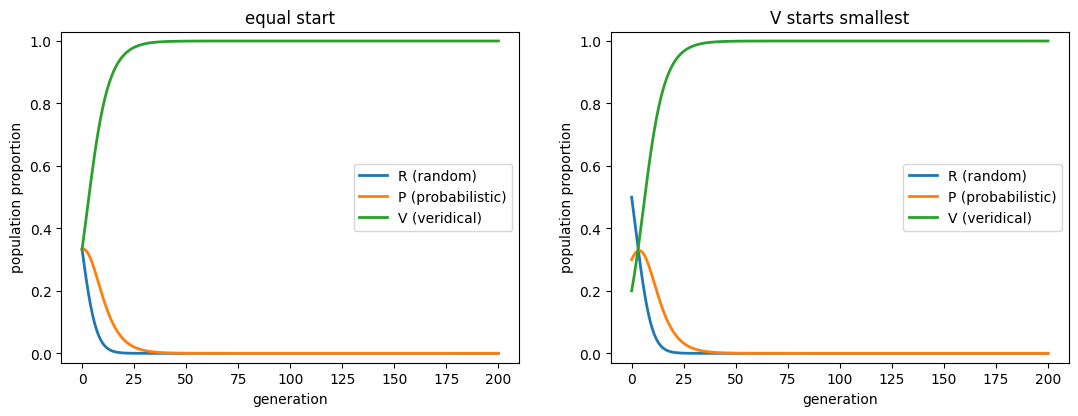

final from [0.5,0.3,0.2]: [0. 0. 1.]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ev.plot_run(p, [1/3, 1/3, 1/3], 200, ev.STRATEGY_LABELS,
            ax=axes[0], title="equal start")
ev.plot_run(p, [0.5, 0.3, 0.2], 200, ev.STRATEGY_LABELS,
            ax=axes[1], title="V starts smallest")
plt.show()
print("final from [0.5,0.3,0.2]:",
      np.round(ev.run(p, [0.5, 0.3, 0.2], 200)[-1], 3))

## Every path leads to the V vertex

The three-strategy state lives on a triangle (the 2-simplex). Plot
trajectories from many starts &mdash; all flow to the veridical
corner.

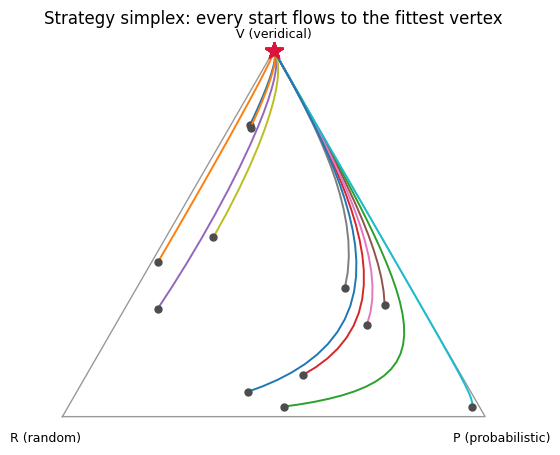

In [5]:
rng = np.random.default_rng(1)
starts = [rng.dirichlet(np.ones(3)) for _ in range(12)]
ev.plot_simplex_trajectory(p, starts, 200)
plt.show()

## The Lemma: a clean closed form

The clunky matrix $W(t)$ hides a tidy update. With $\circ$ the
elementwise product,
$$ s(t+1) = p \circ s + s\,\langle \vec 1 - p,\ s\rangle. $$
The module offers three equivalent implementations and a checker
that confirms they agree &mdash; in **any** dimension.

In [6]:
print("Lemma holds for the worked example:", ev.verify_lemma(p, s))
rng = np.random.default_rng(0)
ok = all(ev.verify_lemma(rng.random(n), rng.dirichlet(np.ones(n)))
         for n in (2, 3, 4, 5, 8) for _ in range(50))
print("Lemma holds across 250 random cases, dims 2..8:", ok)

Lemma holds for the worked example: True
Lemma holds across 250 random cases, dims 2..8: True


## The (empirical) Theorem

If one strategy has strictly greatest fitness, its proportion tends
to 1 and the rest to 0. A formal proof eluded the original paper,
but the evidence is overwhelming:

In [7]:
rng = np.random.default_rng(2)
wins3 = sum(ev.dominant_strategy_wins(p, rng.dirichlet(np.ones(3)))
            for _ in range(300))
print(f"3-D: fittest strategy won {wins3}/300 random starts")
for n in (4, 6, 10):
    pv = rng.random(n)
    w = sum(ev.dominant_strategy_wins(pv, rng.dirichlet(np.ones(n)))
            for _ in range(50))
    print(f"{n}-D: fittest won {w}/50")

3-D: fittest strategy won 300/300 random starts


4-D: fittest won 50/50


6-D: fittest won 50/50


10-D: fittest won 50/50


## The reversal: charge V for its computation time

Nothing above explains *why* V should be fittest &mdash; that's an
input. If accurate perception is costly, model that by lowering V's
effective fitness. Drop it below P's and the outcome flips: the
veridical strategy now goes **extinct**.

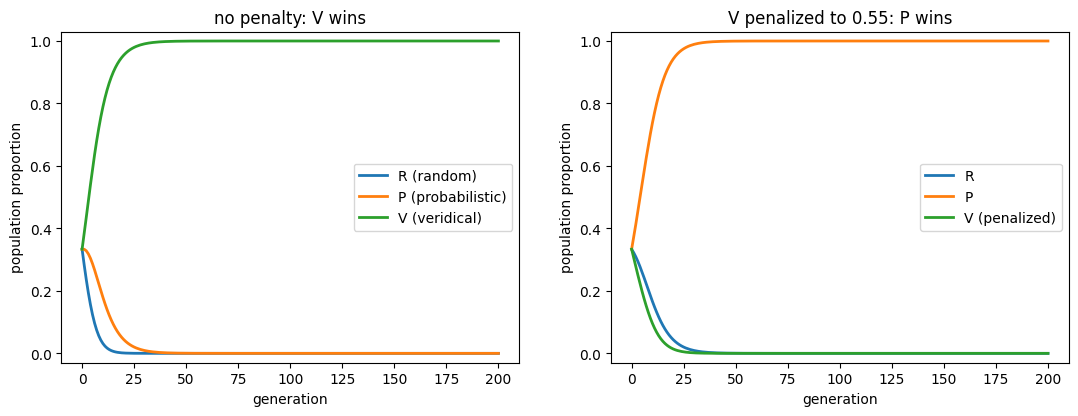

penalized winner index (0=R,1=P,2=V): 1


In [8]:
p_penalized = np.array([0.6, 0.75, 0.55])   # V's fitness cut by a time cost
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ev.plot_run(p, [1/3]*3, 200, ev.STRATEGY_LABELS,
            ax=axes[0], title="no penalty: V wins")
ev.plot_run(p_penalized, [1/3]*3, 200,
            ["R", "P", "V (penalized)"],
            ax=axes[1], title="V penalized to 0.55: P wins")
plt.show()
print("penalized winner index (0=R,1=P,2=V):",
      int(np.argmax(ev.run(p_penalized, [1/3]*3, 300)[-1])))

## Your turn

1. Where exactly is the tipping point? Sweep V's fitness from 0.5 to
   0.9 and find the value at which the winner switches from P to V.
2. Add a fourth strategy and confirm the Theorem still picks the
   unique fittest.
3. The spatial experiment (movement + per-individual strategies +
   a move-order time penalty) is described in the book. As a
   project, extend `cadyn.ecosystem` to reproduce it &mdash; the
   mean-field model here is your validated target.

> **Connection.** This is a concrete, spatial instance of Hoffman's
> *Interface Theory of Perception*: evolution optimizes fitness, not
> truth, and the two can diverge once perception has a cost.